In [14]:
import polars as pl

catalina_path = "/home/rohan/agn_photometry/photometry/results/catalina_photometry.parquet"
alerce_path   = "/home/rohan/agn_photometry/photometry/results/alerce_photometry.parquet"
atlas_path    = "/home/rohan/agn_photometry/photometry/results/atlas_photometry.parquet"

# outputs for this new analysis live under structure_function_fractional_variability/results
sf_fvar_results_dir = "/home/rohan/agn_photometry/structure_function_fractional_variability/results"

df_catalina = pl.read_parquet(catalina_path)
df_alerce   = pl.read_parquet(alerce_path)
df_atlas    = pl.read_parquet(atlas_path)

def cadence_summary(df, time_col, group_cols, survey_name):
    return (
        df.group_by(group_cols)
        .agg([
            pl.len().alias("N"),
            (pl.col(time_col).max() - pl.col(time_col).min()).alias("baseline_days"),
        ])
        .with_columns(pl.lit(survey_name).alias("survey"))
        .sort("N", descending=True)
    )

catalina_cadence = cadence_summary(
    df_catalina, "MJD", ["source_name"], "Catalina"
).with_columns(pl.lit(None, dtype=pl.Utf8).alias("band"))

alerce_cadence = cadence_summary(
    df_alerce, "mjd", ["source_name", "fid"], "ALERCE"
).rename({"fid": "band"}).with_columns(pl.col("band").cast(pl.Utf8))

atlas_cadence = cadence_summary(
    df_atlas, "MJD", ["source_name", "F"], "ATLAS"
).rename({"F": "band"}).with_columns(pl.col("band").cast(pl.Utf8))

cadence_all = pl.concat(
    [catalina_cadence, alerce_cadence, atlas_cadence],
    how="diagonal",
).select(["survey", "source_name", "band", "N", "baseline_days"])

# Tiering: N >= 50 and baseline >= 365d -> trusted; N >= 20 -> marginal; else -> excluded
cadence_all = cadence_all.with_columns(
    pl.when((pl.col("N") >= 50) & (pl.col("baseline_days") >= 365))
      .then(pl.lit("trusted"))
      .when(pl.col("N") >= 20)
      .then(pl.lit("marginal"))
      .otherwise(pl.lit("excluded"))
      .alias("tier")
)

pl.Config.set_tbl_rows(-1)
print(cadence_all)

print("\nTier counts by survey:")
print(cadence_all.group_by(["survey", "tier"]).agg(pl.len().alias("count")).sort(["survey", "tier"]))

output_path = f"{sf_fvar_results_dir}/cadence_summary.parquet"
cadence_all.write_parquet(output_path)
print(f"\nSaved to {output_path}")

shape: (127, 6)
┌──────────┬────────────────────┬──────┬──────┬───────────────┬──────────┐
│ survey   ┆ source_name        ┆ band ┆ N    ┆ baseline_days ┆ tier     │
│ ---      ┆ ---                ┆ ---  ┆ ---  ┆ ---           ┆ ---      │
│ str      ┆ str                ┆ str  ┆ u64  ┆ f64           ┆ str      │
╞══════════╪════════════════════╪══════╪══════╪═══════════════╪══════════╡
│ Catalina ┆ 110104.14+062829.5 ┆ null ┆ 897  ┆ 3166.16978    ┆ trusted  │
│ Catalina ┆ 161742.53+322234.4 ┆ null ┆ 727  ┆ 3078.76041    ┆ trusted  │
│ Catalina ┆ 095919.14+090659.4 ┆ null ┆ 689  ┆ 3180.26115    ┆ trusted  │
│ Catalina ┆ 150348.33+193941.3 ┆ null ┆ 670  ┆ 3032.83473    ┆ trusted  │
│ Catalina ┆ 093856.54+435415.0 ┆ null ┆ 669  ┆ 2902.07766    ┆ trusted  │
│ Catalina ┆ 121028.83+025454.2 ┆ null ┆ 504  ┆ 2999.88549    ┆ trusted  │
│ Catalina ┆ 022325.01-003612.6 ┆ null ┆ 493  ┆ 2963.95944    ┆ trusted  │
│ Catalina ┆ 075005.28+292944.3 ┆ null ┆ 473  ┆ 3090.31711    ┆ trusted  │
│ Catalin

In [15]:
import polars as pl
import numpy as np

catalina_path  = "/home/rohan/agn_photometry/photometry/results/catalina_photometry.parquet"
alerce_path    = "/home/rohan/agn_photometry/photometry/results/alerce_photometry.parquet"
atlas_path     = "/home/rohan/agn_photometry/photometry/results/atlas_photometry.parquet"
cadence_path   = "/home/rohan/agn_photometry/structure_function_fractional_variability/results/cadence_summary.parquet"

df_catalina = pl.read_parquet(catalina_path)
df_alerce   = pl.read_parquet(alerce_path)
df_atlas    = pl.read_parquet(atlas_path)
cadence     = pl.read_parquet(cadence_path)

def remove_outliers_mask(mag_vals, threshold=4.0):
    """Same MAD-based logic as Photometry.ipynb's remove_outliers, returns a boolean mask."""
    y_arr = mag_vals.to_numpy()
    n = len(y_arr)
    if n < 3:
        return np.ones(n, dtype=bool)
    median = np.median(y_arr)
    mad = np.median(np.abs(y_arr - median))
    if mad == 0:
        return np.ones(n, dtype=bool)
    modified_z = 0.6745 * (y_arr - median) / mad
    return np.abs(modified_z) < threshold

def apply_mad_filter(df, mag_col, group_cols, err_col=None):
    """Apply MAD outlier removal independently within each (source, band) group.
    If err_col is given, points that are outliers in EITHER mag or error are dropped."""
    kept_frames = []
    for _, sub in df.group_by(group_cols):
        mask = remove_outliers_mask(sub[mag_col])
        if err_col is not None:
            err_mask = remove_outliers_mask(sub[err_col])
            mask = mask & err_mask
        kept_frames.append(sub.filter(pl.Series(mask)))
    return pl.concat(kept_frames)

df_catalina = apply_mad_filter(df_catalina, "mag", ["source_name"], err_col="mag_err")
df_alerce   = apply_mad_filter(df_alerce, "magpsf_corr", ["source_name", "fid"], err_col="sigmapsf")
df_atlas    = apply_mad_filter(df_atlas, "m", ["source_name", "F"], err_col="dm")
df_atlas = df_atlas.rename({"F": "band"})

# ---- mag -> flux, per row ----
def add_flux_cols(df, mag_col, magerr_col):
    return df.with_columns([
        (10 ** (-0.4 * pl.col(mag_col))).alias("F"),
    ]).with_columns([
        (0.4 * np.log(10) * pl.col("F") * pl.col(magerr_col)).alias("sigma_F"),
    ])

df_catalina = add_flux_cols(df_catalina, "mag", "mag_err").with_columns(
    pl.lit(None, dtype=pl.Utf8).alias("band")
)
df_alerce = add_flux_cols(df_alerce, "magpsf_corr", "sigmapsf").with_columns(
    pl.col("fid").cast(pl.Utf8).alias("band")
)
df_atlas = add_flux_cols(df_atlas, "m", "dm").with_columns(
    pl.col("band").cast(pl.Utf8)
)

df_catalina = df_catalina.with_columns(pl.lit("Catalina").alias("survey"))
df_alerce   = df_alerce.with_columns(pl.lit("ALERCE").alias("survey"))
df_atlas    = df_atlas.with_columns(pl.lit("ATLAS").alias("survey"))

# ---- Fvar per (survey, source_name, band) ----
def fvar_per_group(df):
    return (
        df.group_by(["survey", "source_name", "band"])
        .agg([
            pl.len().alias("N"),
            pl.col("F").mean().alias("F_mean"),
            pl.col("F").var(ddof=1).alias("S2"),
            (pl.col("sigma_F") ** 2).mean().alias("sigma2_err_mean"),
        ])
        .with_columns(
            ((pl.col("S2") - pl.col("sigma2_err_mean")) / (pl.col("F_mean") ** 2))
            .alias("excess_var_norm")
        )
        .with_columns(
            pl.when(pl.col("excess_var_norm") > 0)
              .then(pl.col("excess_var_norm").sqrt())
              .otherwise(None)
              .alias("Fvar")
        )
    )

fvar_catalina = fvar_per_group(df_catalina)
fvar_alerce   = fvar_per_group(df_alerce)
fvar_atlas    = fvar_per_group(df_atlas)

fvar_all = pl.concat([fvar_catalina, fvar_alerce, fvar_atlas], how="diagonal")

# ---- join cadence tiers, drop excluded ----
fvar_all = fvar_all.join(
    cadence.select(["survey", "source_name", "band", "baseline_days", "tier"]),
    on=["survey", "source_name", "band"],
    how="left",
    nulls_equal=True,
)

fvar_trusted = fvar_all.filter(pl.col("tier") != "excluded")

pl.Config.set_tbl_rows(-1)
print(fvar_trusted.select([
    "survey", "source_name", "band", "N", "baseline_days", "tier", "Fvar"
]).sort(["survey", "source_name"]))

output_path = "/home/rohan/agn_photometry/structure_function_fractional_variability/results/fvar_all_surveys.parquet"
fvar_trusted.write_parquet(output_path)
print(f"\nSaved to {output_path}")

shape: (108, 7)
┌──────────┬────────────────────┬──────┬──────┬───────────────┬──────────┬──────────┐
│ survey   ┆ source_name        ┆ band ┆ N    ┆ baseline_days ┆ tier     ┆ Fvar     │
│ ---      ┆ ---                ┆ ---  ┆ ---  ┆ ---           ┆ ---      ┆ ---      │
│ str      ┆ str                ┆ str  ┆ u64  ┆ f64           ┆ str      ┆ f64      │
╞══════════╪════════════════════╪══════╪══════╪═══════════════╪══════════╪══════════╡
│ ALERCE   ┆ 001255.59+014750.9 ┆ 1    ┆ 195  ┆ 2305.698507   ┆ trusted  ┆ 0.224405 │
│ ALERCE   ┆ 001255.59+014750.9 ┆ 2    ┆ 103  ┆ 2297.776586   ┆ trusted  ┆ 0.09675  │
│ ALERCE   ┆ 022325.01-003612.6 ┆ 1    ┆ 136  ┆ 1537.936331   ┆ trusted  ┆ null     │
│ ALERCE   ┆ 075947.73+112507.3 ┆ 2    ┆ 112  ┆ 1086.917338   ┆ trusted  ┆ null     │
│ ALERCE   ┆ 075947.73+112507.3 ┆ 1    ┆ 83   ┆ 1108.989977   ┆ trusted  ┆ 0.130613 │
│ ALERCE   ┆ 082311.26+435318.5 ┆ 2    ┆ 24   ┆ 370.015567    ┆ marginal ┆ null     │
│ ALERCE   ┆ 095746.83+303024.2 ┆ 1   

In [16]:
import polars as pl
import numpy as np

catalina_path = "/home/rohan/agn_photometry/photometry/results/catalina_photometry.parquet"
alerce_path   = "/home/rohan/agn_photometry/photometry/results/alerce_photometry.parquet"

df_catalina = pl.read_parquet(catalina_path)
df_alerce   = pl.read_parquet(alerce_path)

print("=" * 70)
print("CATALINA: 205601.38-062049.7 (Fvar = 3.46 outlier)")
print("=" * 70)
sub = df_catalina.filter(pl.col("source_name") == "205601.38-062049.7")
print(f"N = {sub.height}")
print(sub.select(["MJD", "mag", "mag_err"]).describe())
print("\nSorted by mag (brightest and faintest 5 points):")
print(sub.sort("mag").select(["MJD", "mag", "mag_err"]).head(5))
print(sub.sort("mag").select(["MJD", "mag", "mag_err"]).tail(5))

print("\n" + "=" * 70)
print("ALERCE: 132404.20+433407.1 (null Fvar in BOTH bands despite N=225/139)")
print("=" * 70)
sub2 = df_alerce.filter(pl.col("source_name") == "132404.20+433407.1")
print(f"Total N (both bands) = {sub2.height}")
for band in sub2["fid"].unique().sort():
    b = sub2.filter(pl.col("fid") == band)
    print(f"\n--- fid={band}, N={b.height} ---")
    print(b.select(["magpsf_corr", "sigmapsf"]).describe())

CATALINA: 205601.38-062049.7 (Fvar = 3.46 outlier)
N = 326
shape: (9, 4)
┌────────────┬──────────────┬───────────┬──────────┐
│ statistic  ┆ MJD          ┆ mag       ┆ mag_err  │
│ ---        ┆ ---          ┆ ---       ┆ ---      │
│ str        ┆ f64          ┆ f64       ┆ f64      │
╞════════════╪══════════════╪═══════════╪══════════╡
│ count      ┆ 326.0        ┆ 326.0     ┆ 326.0    │
│ null_count ┆ 0.0          ┆ 0.0       ┆ 0.0      │
│ mean       ┆ 55054.772015 ┆ 19.155706 ┆ 0.199908 │
│ std        ┆ 951.914692   ┆ 0.445421  ┆ 0.045088 │
│ min        ┆ 53525.3978   ┆ 14.37     ┆ 0.13     │
│ 25%        ┆ 54233.44104  ┆ 18.95     ┆ 0.17     │
│ 50%        ┆ 55058.26778  ┆ 19.12     ┆ 0.19     │
│ 75%        ┆ 55850.15842  ┆ 19.37     ┆ 0.22     │
│ max        ┆ 56593.12599  ┆ 20.38     ┆ 0.5      │
└────────────┴──────────────┴───────────┴──────────┘

Sorted by mag (brightest and faintest 5 points):
shape: (5, 3)
┌─────────────┬───────┬─────────┐
│ MJD         ┆ mag   ┆ mag_err │


In [17]:
import polars as pl
import numpy as np

atlas_path = "/home/rohan/agn_photometry/photometry/results/atlas_photometry.parquet"
df_atlas = pl.read_parquet(atlas_path)

# Same MAD filter as the main pipeline, applied here for a fair comparison
def remove_outliers_mask(mag_vals, threshold=4.0):
    y_arr = mag_vals.to_numpy()
    n = len(y_arr)
    if n < 3:
        return np.ones(n, dtype=bool)
    median = np.median(y_arr)
    mad = np.median(np.abs(y_arr - median))
    if mad == 0:
        return np.ones(n, dtype=bool)
    modified_z = 0.6745 * (y_arr - median) / mad
    return np.abs(modified_z) < threshold

sources_to_check = ["001255.59+014750.9", "113618.90+125554.8", "150348.33+193941.3"]

for src in sources_to_check:
    print("=" * 70)
    print(f"{src}")
    print("=" * 70)
    for band in ["c", "o"]:
        sub = df_atlas.filter(
            (pl.col("source_name") == src) & (pl.col("F") == band)
        )
        mag_mask = remove_outliers_mask(sub["m"])
        err_mask = remove_outliers_mask(sub["dm"])
        mask = mag_mask & err_mask
        sub_clean = sub.filter(pl.Series(mask))

        m = sub_clean["m"].to_numpy()
        dm = sub_clean["dm"].to_numpy()
        flux = 10 ** (-0.4 * m)
        sigma_flux = 0.4 * np.log(10) * flux * dm

        S2 = np.var(flux, ddof=1)
        sigma2_err_mean = np.mean(sigma_flux ** 2)
        excess = S2 - sigma2_err_mean

        print(f"\n--- band={band}, N={len(m)} (after MAD filter) ---")
        print(f"  mag std      = {np.std(m):.5f}")
        print(f"  mean dm      = {np.mean(dm):.5f}")
        print(f"  median dm    = {np.median(dm):.5f}")
        print(f"  max dm       = {np.max(dm):.5f}")
        print(f"  flux S2      = {S2:.6e}")
        print(f"  mean sigma_F^2 = {sigma2_err_mean:.6e}")
        print(f"  excess (S2 - sigma2_err_mean) = {excess:.6e}  {'-> NEGATIVE (null Fvar)' if excess <= 0 else '-> positive'}")

001255.59+014750.9

--- band=c, N=215 (after MAD filter) ---
  mag std      = 0.80841
  mean dm      = 0.63373
  median dm    = 0.44300
  max dm       = 2.10500
  flux S2      = 2.626101e-16
  mean sigma_F^2 = 2.403095e-16
  excess (S2 - sigma2_err_mean) = 2.230060e-17  -> positive

--- band=o, N=1028 (after MAD filter) ---
  mag std      = 1.05728
  mean dm      = 1.15730
  median dm    = 0.84000
  max dm       = 4.26300
  flux S2      = 8.383469e-16
  mean sigma_F^2 = 1.493008e-15
  excess (S2 - sigma2_err_mean) = -6.546615e-16  -> NEGATIVE (null Fvar)
113618.90+125554.8

--- band=c, N=580 (after MAD filter) ---
  mag std      = 0.92397
  mean dm      = 1.20887
  median dm    = 0.88650
  max dm       = 4.09500
  flux S2      = 9.599432e-17
  mean sigma_F^2 = 1.104922e-16
  excess (S2 - sigma2_err_mean) = -1.449786e-17  -> NEGATIVE (null Fvar)

--- band=o, N=2260 (after MAD filter) ---
  mag std      = 0.89123
  mean dm      = 1.07261
  median dm    = 0.80000
  max dm       = 3.74400


In [18]:
import polars as pl
combined_targets = pl.read_csv("/home/rohan/agn_photometry/data/sdss_meeting_targets_dr18.csv")  # adjust path if needed
print(combined_targets.columns)
print(combined_targets["Name of the source"].head(10))

['Name of the source', 'RA', 'DEC', 'redshift', 'FIBER', 'MJD', 'PLATE', 'Link']
shape: (10,)
Series: 'Name of the source' [str]
[
	"103346.74+365244.5"
	"095919.14+090659.4"
	"140325.82+443014.1"
	"155344.41+063913.1"
	"092730.38+415004.5"
	"113330.30+105223.3"
	"113923.66+002301.6"
	"072939.02+353613.4"
	"092525.16+202139.0"
	"110023.10+001818.1"
]


/tmp/ipykernel_1194/2400621296.py:22: RuntimeWarning: divide by zero encountered in divide
  "R_Fe": (fits_data["FEII_OPT_EW"] / hb_ew).astype(float),
/tmp/ipykernel_1194/2400621296.py:22: RuntimeWarning: invalid value encountered in divide
  "R_Fe": (fits_data["FEII_OPT_EW"] / hb_ew).astype(float),


Extracted 750414 FITS rows with R_Fe and fwhm_hbeta
Fvar table: 108 rows
Merged table saved: /home/rohan/agn_photometry/structure_function_fractional_variability/results/fvar_with_ev1.parquet
✓ Fvar vs FWHM(Hβ) plots saved
✓ Fvar vs R_FeII plots saved

✓✓✓ Done. Two PDFs ready for presentation.


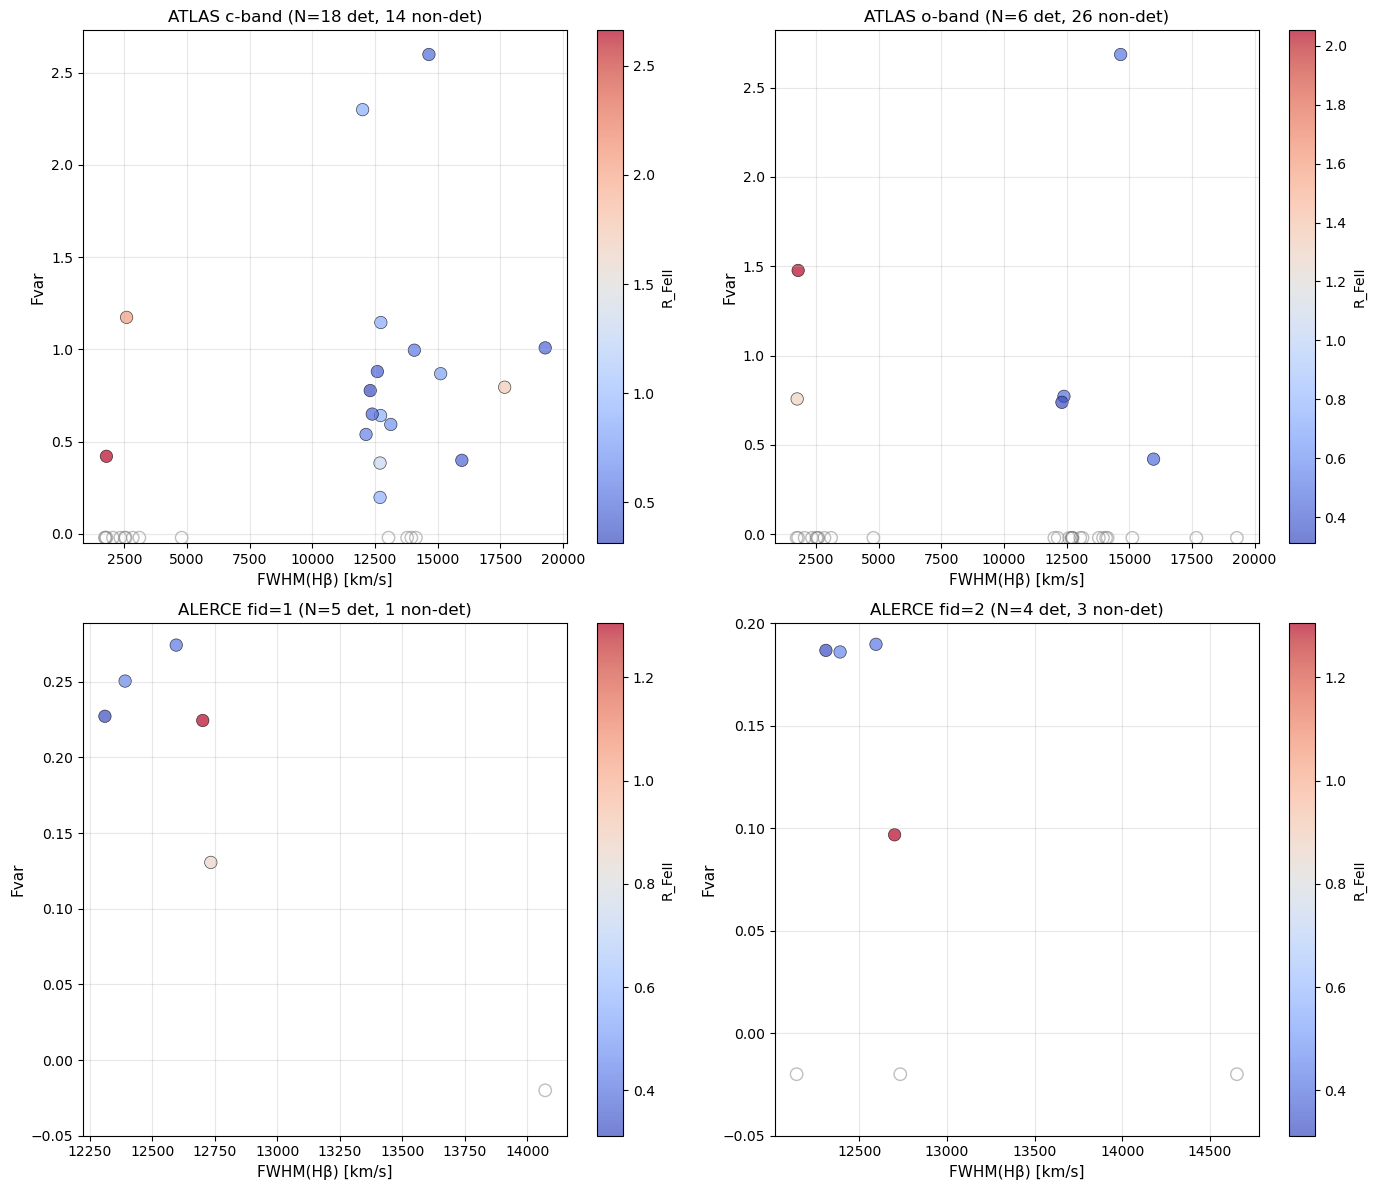

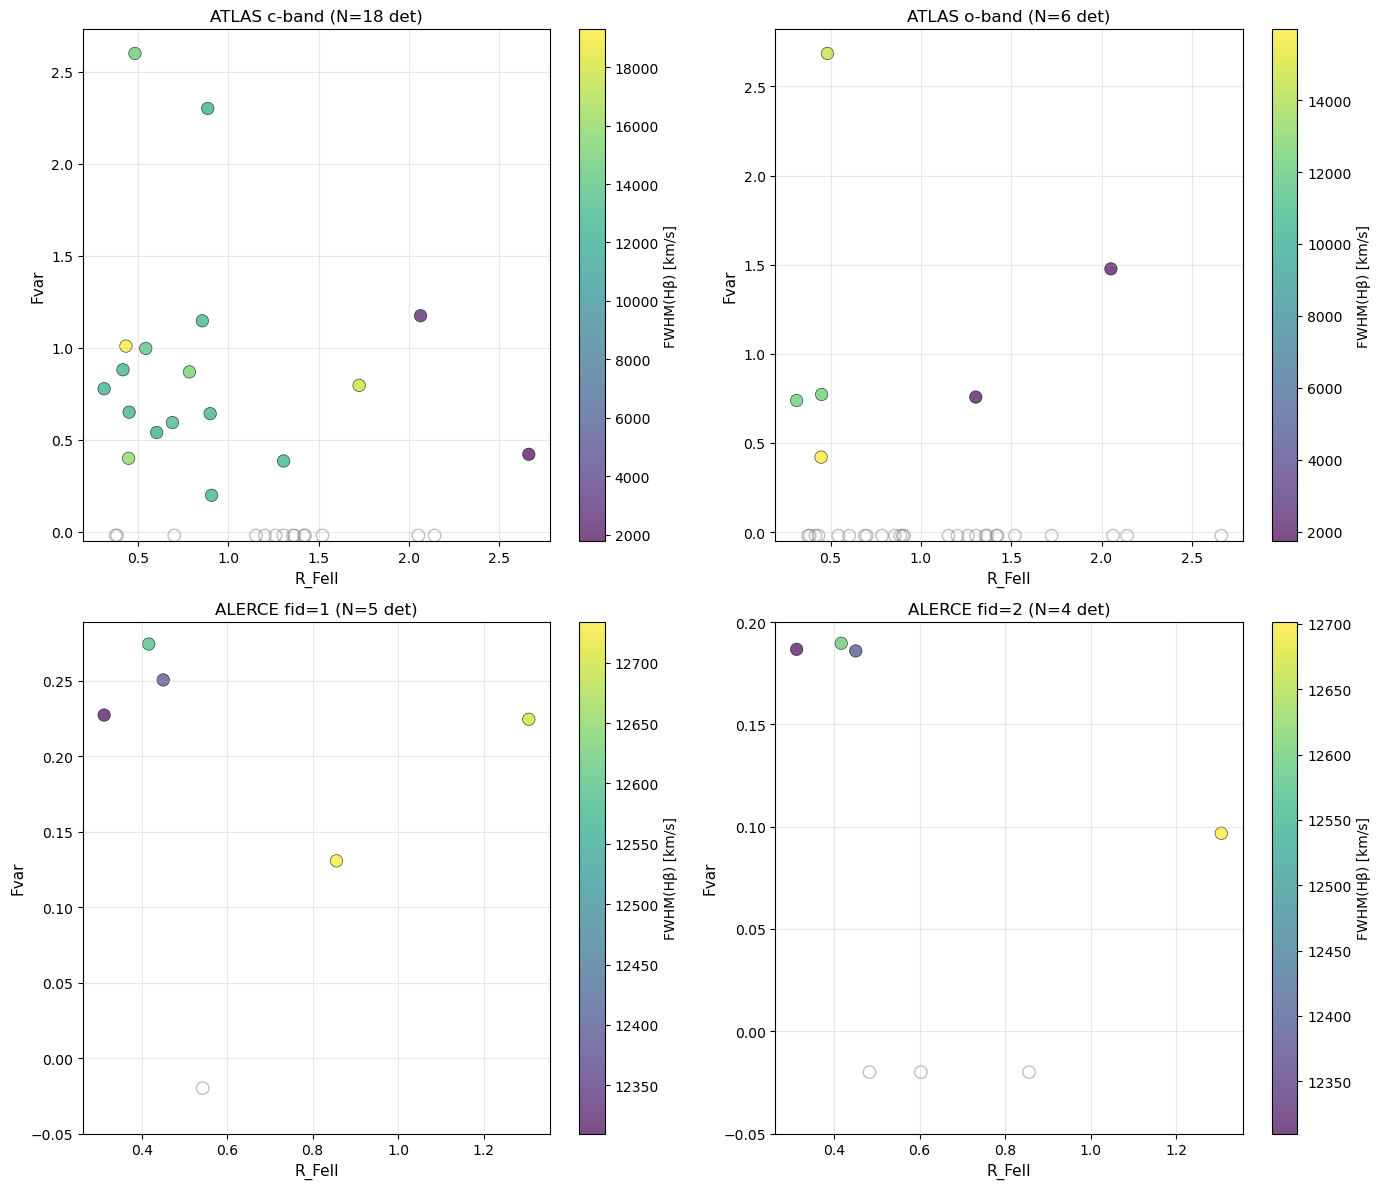

In [19]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import fitsio

# ---- Step 1: Extract R_Fe and fwhm_hbeta from FITS ----
fits_path = "/home/rohan/agn_photometry/data/dr16q_prop_May01_2024.fits"
cols_to_read = ["SDSS_NAME", "PLATE", "MJD", "FIBERID", "RA", "DEC", "FEII_OPT_EW", "HBETA_BR"]
fits_data = fitsio.read(fits_path, columns=cols_to_read)

# Extract R_Fe and fwhm_hbeta from HBETA_BR array
hb_ew = fits_data["HBETA_BR"][:, 3]  # Position 3 = EW
hb_fwhm = fits_data["HBETA_BR"][:, 4]  # Position 4 = FWHM

df_fits = pl.DataFrame({
    "source_name": fits_data["SDSS_NAME"].astype(str),
    "PLATE": fits_data["PLATE"].astype(int),
    "MJD": fits_data["MJD"].astype(int),
    "FIBERID": fits_data["FIBERID"].astype(int),
    "RA": fits_data["RA"].astype(float),
    "DEC": fits_data["DEC"].astype(float),
    "R_Fe": (fits_data["FEII_OPT_EW"] / hb_ew).astype(float),
    "fwhm_hbeta": hb_fwhm.astype(float),
})

print(f"Extracted {df_fits.height} FITS rows with R_Fe and fwhm_hbeta")

# ---- Step 2: Load Fvar table ----
fvar_path = "/home/rohan/agn_photometry/structure_function_fractional_variability/results/fvar_all_surveys.parquet"
df_fvar = pl.read_parquet(fvar_path)
print(f"Fvar table: {df_fvar.height} rows")

# ---- Step 3: Merge Fvar + EV1 values ----
df_merged = df_fvar.join(
    df_fits.select(["source_name", "R_Fe", "fwhm_hbeta"]),
    on="source_name",
    how="left",
)

output_merged = "/home/rohan/agn_photometry/structure_function_fractional_variability/results/fvar_with_ev1.parquet"
df_merged.write_parquet(output_merged)
print(f"Merged table saved: {output_merged}")

# ---- Step 4: Create four Fvar scatter plots (one per band) ----
bands_to_plot = [
    ("ATLAS", "c", "ATLAS c-band"),
    ("ATLAS", "o", "ATLAS o-band"),
    ("ALERCE", "1", "ALERCE fid=1"),
    ("ALERCE", "2", "ALERCE fid=2"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (survey, band, title) in enumerate(bands_to_plot):
    ax = axes[idx]
    
    subset = df_merged.filter((pl.col("survey") == survey) & (pl.col("band") == band))
    detected = subset.filter(pl.col("Fvar").is_not_null())
    non_detected = subset.filter(pl.col("Fvar").is_null())
    
    if detected.height > 0:
        x_det = detected["fwhm_hbeta"].to_numpy()
        y_det = detected["Fvar"].to_numpy()
        c_det = detected["R_Fe"].to_numpy()
        
        scatter = ax.scatter(x_det, y_det, c=c_det, cmap="coolwarm", s=80, alpha=0.7, 
                           edgecolors="black", linewidth=0.5)
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label("R_FeII", fontsize=10)
    
    if non_detected.height > 0:
        x_nd = non_detected["fwhm_hbeta"].to_numpy()
        y_nd = np.full_like(x_nd, -0.02, dtype=float)
        ax.scatter(x_nd, y_nd, marker="o", facecolors="none", edgecolors="gray", 
                 s=80, alpha=0.5, label="Non-detected")
    
    ax.set_xlabel("FWHM(Hβ) [km/s]", fontsize=11)
    ax.set_ylabel("Fvar", fontsize=11)
    ax.set_title(f"{title} (N={detected.height} det, {non_detected.height} non-det)", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, None)

plt.tight_layout()
plt.savefig("/home/rohan/agn_photometry/structure_function_fractional_variability/results/fvar_vs_fwhm.pdf", dpi=150)
print("✓ Fvar vs FWHM(Hβ) plots saved")

# ---- Step 5: Create Fvar vs R_Fe plots ----
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 12))
axes2 = axes2.flatten()

for idx, (survey, band, title) in enumerate(bands_to_plot):
    ax = axes2[idx]
    
    subset = df_merged.filter((pl.col("survey") == survey) & (pl.col("band") == band))
    detected = subset.filter(pl.col("Fvar").is_not_null())
    non_detected = subset.filter(pl.col("Fvar").is_null())
    
    if detected.height > 0:
        x_det = detected["R_Fe"].to_numpy()
        y_det = detected["Fvar"].to_numpy()
        c_det = detected["fwhm_hbeta"].to_numpy()
        
        scatter = ax.scatter(x_det, y_det, c=c_det, cmap="viridis", s=80, alpha=0.7, 
                           edgecolors="black", linewidth=0.5)
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label("FWHM(Hβ) [km/s]", fontsize=10)
    
    if non_detected.height > 0:
        x_nd = non_detected["R_Fe"].to_numpy()
        y_nd = np.full_like(x_nd, -0.02, dtype=float)
        ax.scatter(x_nd, y_nd, marker="o", facecolors="none", edgecolors="gray", 
                 s=80, alpha=0.5, label="Non-detected")
    
    ax.set_xlabel("R_FeII", fontsize=11)
    ax.set_ylabel("Fvar", fontsize=11)
    ax.set_title(f"{title} (N={detected.height} det)", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, None)

plt.tight_layout()
plt.savefig("/home/rohan/agn_photometry/structure_function_fractional_variability/results/fvar_vs_rfe.pdf", dpi=150)
print("✓ Fvar vs R_FeII plots saved")

print("\n✓✓✓ Done. Two PDFs ready for presentation.")

In [2]:
import polars as pl

# Read the CSV
df = pl.read_csv("/home/rohan/agn_photometry/structure_function_fractional_variability/programs/csv_export/fvar_all_surveys.csv")

# Filter for ATLAS o-band
atlas_o = df.filter((pl.col("survey") == "ATLAS") & (pl.col("band") == "o"))

# Count nulls in Fvar column
null_count = atlas_o.filter(pl.col("Fvar").is_null()).height
total_count = atlas_o.height

print(f"ATLAS o-band: {null_count} nulls out of {total_count} rows")
print(atlas_o.select(["source_name", "band", "Fvar"]))

ATLAS o-band: 26 nulls out of 32 rows
shape: (32, 3)
┌────────────────────┬──────┬──────────┐
│ source_name        ┆ band ┆ Fvar     │
│ ---                ┆ ---  ┆ ---      │
│ str                ┆ str  ┆ f64      │
╞════════════════════╪══════╪══════════╡
│ 152942.19+350851.3 ┆ o    ┆ 0.772021 │
│ 143947.10+421317.3 ┆ o    ┆ null     │
│ 083325.69+391204.7 ┆ o    ┆ null     │
│ 090550.30+003948.1 ┆ o    ┆ null     │
│ 172052.29+590153.7 ┆ o    ┆ null     │
│ …                  ┆ …    ┆ …        │
│ 121028.83+025454.2 ┆ o    ┆ null     │
│ 140655.51+582200.0 ┆ o    ┆ null     │
│ 075947.73+112507.3 ┆ o    ┆ null     │
│ 153145.14+431933.8 ┆ o    ┆ null     │
│ 084245.18+445533.9 ┆ o    ┆ null     │
└────────────────────┴──────┴──────────┘


In [5]:
import polars as pl

df = pl.read_parquet("/home/rohan/agn_photometry/structure_function_fractional_variability/results/fvar_all_surveys.parquet")

# Group by survey and band, count nulls
summary = df.group_by(["survey", "band"]).agg([
    pl.len().alias("total"),
    pl.col("Fvar").is_null().sum().alias("nulls"),
]).with_columns(
    (pl.col("nulls") / pl.col("total") * 100).alias("null_percent")
).sort(["survey", "band"])

print(summary)

shape: (5, 5)
┌──────────┬──────┬───────┬───────┬──────────────┐
│ survey   ┆ band ┆ total ┆ nulls ┆ null_percent │
│ ---      ┆ ---  ┆ ---   ┆ ---   ┆ ---          │
│ str      ┆ str  ┆ u64   ┆ u64   ┆ f64          │
╞══════════╪══════╪═══════╪═══════╪══════════════╡
│ ALERCE   ┆ 1    ┆ 6     ┆ 1     ┆ 16.666667    │
│ ALERCE   ┆ 2    ┆ 7     ┆ 3     ┆ 42.857143    │
│ ATLAS    ┆ c    ┆ 32    ┆ 14    ┆ 43.75        │
│ ATLAS    ┆ o    ┆ 32    ┆ 26    ┆ 81.25        │
│ Catalina ┆ null ┆ 31    ┆ 3     ┆ 9.677419     │
└──────────┴──────┴───────┴───────┴──────────────┘


In [6]:
import fitsio

fits = fitsio.FITS("/home/rohan/agn_photometry/data/dr16q_prop_May01_2024.fits")
colnames = fits[1].get_colnames()
print(colnames)
fits.close()

['SDSS_NAME', 'PLATE', 'MJD', 'FIBERID', 'RA', 'DEC', 'OBJID', 'IF_BOSS_SDSS', 'Z_DR16Q', 'SOURCE_Z_DR16Q', 'Z_FIT', 'Z_SYS', 'Z_SYS_ERR', 'EBV', 'SN_MEDIAN_ALL', 'CONTI_FIT', 'CONTI_FIT_ERR', 'CONTI_STAT', 'FEII_UV', 'FEII_UV_ERR', 'FEII_UV_EW', 'FEII_UV_EW_ERR', 'FEII_OPT', 'FEII_OPT_ERR', 'FEII_OPT_EW', 'FEII_OPT_EW_ERR', 'LOGL1350', 'LOGL1350_ERR', 'LOGL1700', 'LOGL1700_ERR', 'LOGL2500', 'LOGL2500_ERR', 'LOGL3000', 'LOGL3000_ERR', 'LOGL5100', 'LOGL5100_ERR', 'HALPHA', 'HALPHA_BR', 'NII6585', 'SII6718', 'HBETA', 'HBETA_BR', 'HEII4687', 'HEII4687_BR', 'OIII5007', 'OIII5007C', 'CAII3934', 'OII3728', 'NEV3426', 'MGII', 'MGII_BR', 'CIII_ALL', 'CIII_BR', 'SIIII1892', 'ALIII1857', 'NIII1750', 'CIV', 'HEII1640', 'HEII1640_BR', 'SIIV_OIV', 'OI1304', 'LYA', 'NV1240', 'HALPHA_ERR', 'HALPHA_BR_ERR', 'NII6585_ERR', 'SII6718_ERR', 'HBETA_ERR', 'HBETA_BR_ERR', 'HEII4687_ERR', 'HEII4687_BR_ERR', 'OIII5007_ERR', 'OIII5007C_ERR', 'CAII3934_ERR', 'OII3728_ERR', 'NEV3426_ERR', 'MGII_ERR', 'MGII_BR_ERR